In [1]:
print("Everything is working fine!!")

Everything is working fine!!


# PROBLEN STATEMENT - 
A used-car marketplace wants to build a machine learning system that can estimate the selling
price of a used vehicle based on its characteristics.
You are working as a Junior Machine Learning Engineer. Your task is to analyze historical
used-car data and develop a Multiple Linear Regression model that predicts the price of a
vehicle.
Your solution must not simply train a model and report its accuracy.
You must demonstrate your understanding of:
- Data exploration
- Data cleaning
- Exploratory Data Analysis
- Feature selection
- Categorical variable encoding
- Train-test splitting
- Multiple Linear Regression
- Regression evaluation metrics
- Residual analysis
- Model assumptions
- Multicollinearity
- Overfitting and underfitting
- Feature interpretation
- Model improvement
- Business interpretation

# DATASET - 
The dataset contains approximately 4,009 used-car records with features describing the
vehicle and its condition.
Important attributes include:
- Brand & Model
- Model Year
- Mileage
- Fuel Type
- Engine Type
- Transmission
- Exterior Color
- Interior Color
- Accident History
- Clean Title
- Price

# BUSINESS OBJECTIVE - 
### The company wants to answer:
Given the characteristics of a used car, what should be its expected market price?
Your model should help a seller or buyer estimate a reasonable price.
## Target Variable:
- price
## Input Variables:
- You should investigate which available features can be used to predict price.
- Do not blindly use every column

In [2]:
# Importing dependencies
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Loading Dataset
df = pd.read_csv("C:\\Users\\admin\\OneDrive\\Desktop\\Used-car-price-prediction\\used_cars.csv")
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
df.tail()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [6]:
df.shape

(4009, 12)

In [7]:
df.columns.to_list()

['brand',
 'model',
 'model_year',
 'milage',
 'fuel_type',
 'engine',
 'transmission',
 'ext_col',
 'int_col',
 'accident',
 'clean_title',
 'price']

In [8]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [10]:
# check missing values
print("Missing values:")
df.isnull().sum()

Missing values:


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [11]:
# check duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.rename(columns={
    'brand':'Brand',
    'model':'Model',
    'model_year':'Model_Year',
    'milage':'Milage',
    'fuel_type':'Fuel_Type',
    'engine': 'Engine_Type',
    'transmission':'Transmission',
    'ext_col':'Exterior_Color',
    'int_col':'Interior_Color',
    'accident':'Accident_History',
    'clean_title':'Clean_Title',
    'price':'Price'})

df.head()

,Brand,Model,Model_Year,Milage,Fuel_Type,Engine_Type,Transmission,Exterior_Color,Interior_Color,Accident_History,Clean_Title,Price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [13]:
# change columns into category
cols=['Brand','Model','Fuel_Type','Engine_Type','Transmission','Exterior_Color','Interior_Color','Accident_History','Clean_Title']
for col in cols:
    df[col]=df[col].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Brand             4009 non-null   category
 1   Model             4009 non-null   category
 2   Model_Year        4009 non-null   int64   
 3   Milage            4009 non-null   str     
 4   Fuel_Type         3839 non-null   category
 5   Engine_Type       4009 non-null   category
 6   Transmission      4009 non-null   category
 7   Exterior_Color    4009 non-null   category
 8   Interior_Color    4009 non-null   category
 9   Accident_History  3896 non-null   category
 10  Clean_Title       3413 non-null   category
 11  Price             4009 non-null   str     
dtypes: category(9), int64(1), str(2)
memory usage: 173.5 KB


In [14]:
df.head()

,Brand,Model,Model_Year,Milage,Fuel_Type,Engine_Type,Transmission,Exterior_Color,Interior_Color,Accident_History,Clean_Title,Price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [15]:
# DATA CLEANING
df['Milage'] = (
    df['Milage']
    .str.replace(',', '', regex=False)
    .str.replace(' mi.', '', regex=False)
    .astype(int)
)
df['Milage'].dtype
df['Milage'].head()

0    51000
1    34742
2    22372
3    88900
4     9835
Name: Milage, dtype: int64

In [16]:
df['Milage'] = pd.to_numeric(df['Milage'], errors='coerce')

In [17]:
df['Price'] = (
    df['Price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
df['Price'].dtype
df['Price'].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: Price, dtype: float64

In [18]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [19]:
df[['Milage', 'Price']].head()

,Milage,Price
0,51000,10300.0
1,34742,38005.0
2,22372,54598.0
3,88900,15500.0
4,9835,34999.0


In [20]:
df[['Milage', 'Price']].info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Milage  4009 non-null   int64  
 1   Price   4009 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 62.8 KB


In [21]:
# filling missing values
df['Fuel_Type'].value_counts(dropna=False)

Fuel_Type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [22]:
df['Accident_History'].value_counts(dropna=False)

Accident_History
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [23]:
df['Clean_Title'].value_counts(dropna=False)

Clean_Title
Yes    3413
NaN     596
Name: count, dtype: int64

In [24]:
df['Fuel_Type'] = df['Fuel_Type'].cat.add_categories(['Unknown']).fillna('Unknown')

df['Accident_History'] = df['Accident_History'].cat.add_categories(['Unknown']).fillna('Unknown')

df['Clean_Title'] = df['Clean_Title'].cat.add_categories(['Unknown']).fillna('Unknown')

In [25]:
# Again check missing values
df.isnull().sum()

Brand               0
Model               0
Model_Year          0
Milage              0
Fuel_Type           0
Engine_Type         0
Transmission        0
Exterior_Color      0
Interior_Color      0
Accident_History    0
Clean_Title         0
Price               0
dtype: int64

In [26]:
# REPLACING NOT SUPPOERTED VALUES
df['Fuel_Type'] = df['Fuel_Type'].replace('not supported','Unknown')
df['Fuel_Type'] = df['Fuel_Type'].fillna('Unknown')

In [27]:
df['Fuel_Type'] = df['Fuel_Type'].replace('-','Unknown')
df['Fuel_Type'] = df['Fuel_Type'].fillna('Unknown')

In [28]:
df['Fuel_Type'].value_counts(dropna=False)

Fuel_Type
Gasoline          3309
Hybrid             194
Unknown            172
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        0
Name: count, dtype: int64

In [29]:
df['Engine_Type'].value_counts(dropna=False)

Engine_Type
2.0L I4 16V GDI DOHC Turbo                                          52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel                        48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel                        47
–                                                                   45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel               44
                                                                    ..
Intercooled Turbo Premium Unleaded I-4 2.0 L/122                     1
LAMBDA II 3.8L V-6 gasoline direct injection, DOHC, D-CVVT varia     1
Nettuno 3L V-6 port/direct injection, DOHC, variable valve contr     1
Standard Range Battery                                               1
V8                                                                   1
Name: count, Length: 1146, dtype: int64

In [30]:
df['Engine_Type'] = df['Engine_Type'].replace('-','Unkown')
df['Engine_Type'] = df['Engine_Type'].fillna('Unknown')

In [31]:
df['Interior_Color'].value_counts(dropna=False)

Interior_Color
Black                  2025
Beige                   538
Gray                    472
Brown                   157
–                       133
                       ... 
Tension                   1
Tupelo                    1
Very Light Cashmere       1
WHITE                     1
Whisper Beige             1
Name: count, Length: 156, dtype: int64

In [32]:
df['Interior_Color'] = df['Interior_Color'].replace('-','Unknown')
df['Interior_Color'] = df['Interior_Color'].fillna('Unknown')

In [33]:
df[['Fuel_Type', 'Engine_Type', 'Interior_Color']].isnull().sum()

Fuel_Type         0
Engine_Type       0
Interior_Color    0
dtype: int64

In [34]:
df.describe()

,Model_Year,Milage,Price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


In [35]:
# EDA
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model_Year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
Milage,4009.0,NaN,NaN,NaN,64717.55101,52296.599459,100.0,23044.0,52775.0,94100.0,405000.0
Fuel_Type,4009,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Type,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exterior_Color,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Interior_Color,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accident_History,4009,3,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Model_Year,4009.0,2015.515590,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
Milage,4009.0,64717.551010,52296.599459,100.0,23044.0,52775.0,94100.0,405000.0
Price,4009.0,44553.190322,78710.635554,2000.0,17200.0,31000.0,49990.0,2954083.0


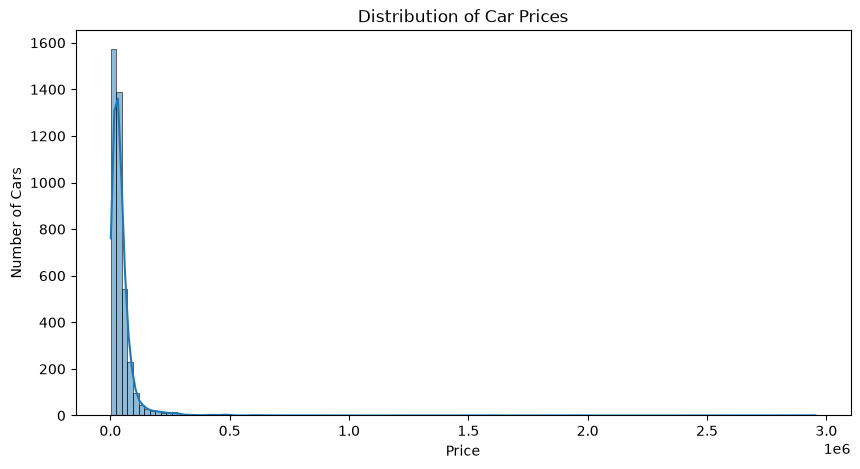

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

In [39]:
print("Price Skewness:", df['Price'].skew())

Price Skewness: 19.51355120421606


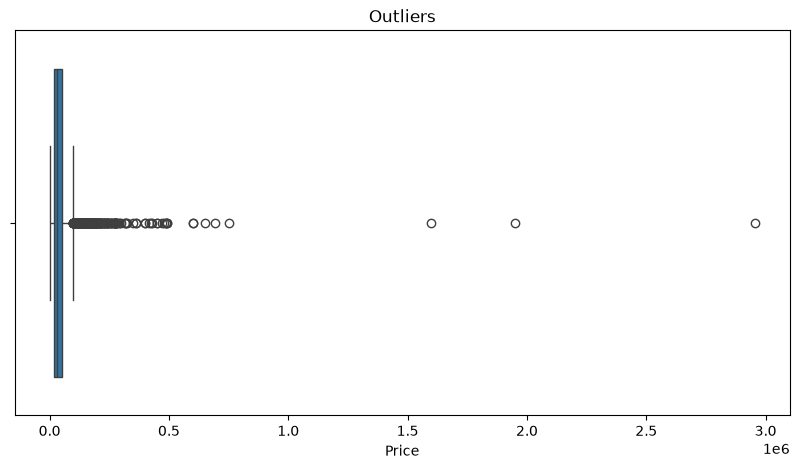

In [40]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Price'])
plt.title('Outliers')
plt.show()

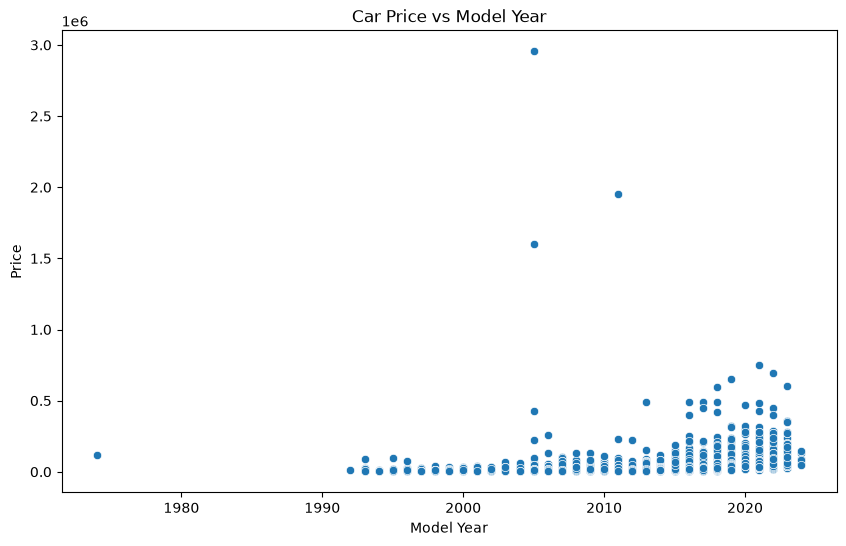

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Model_Year', y='Price')
plt.title('Car Price vs Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.show()

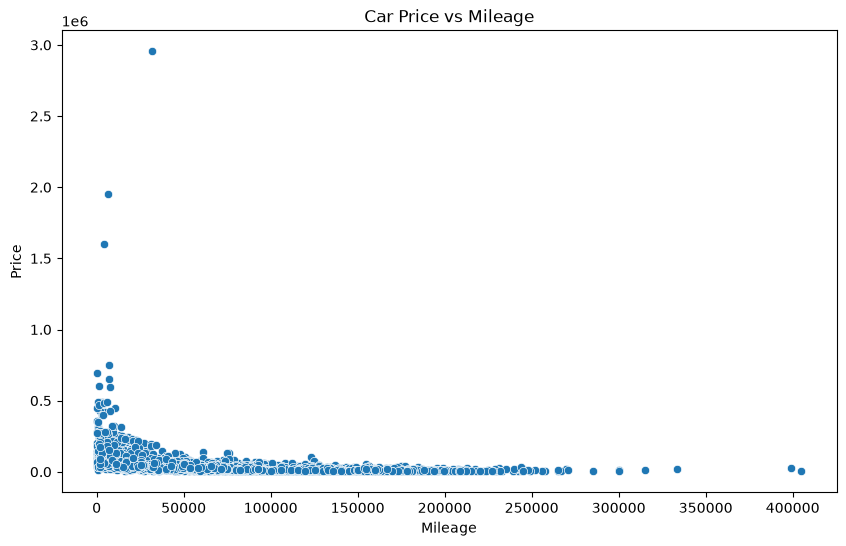

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Milage', y='Price')
plt.title('Car Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [43]:
# Calculating outliers
df['Price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: Price, dtype: float64

In [44]:
df[['Brand', 'Model', 'Price']].sort_values(
    by='Price',
    ascending=False
).head(20)

,Brand,Model,Price
693,Maserati,Quattroporte Base,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,1950995.0
3046,Porsche,Carrera GT Base,1599000.0
1356,Lamborghini,Aventador SVJ Base,749950.0
624,Rolls-Royce,Cullinan,695000.0
979,Lamborghini,Aventador SVJ Base,649999.0
1615,Rolls-Royce,Phantom,599995.0
1508,Rolls-Royce,Phantom,599000.0
3655,Lamborghini,Aventador S Base,491836.0
1061,Dodge,Viper GTC,489995.0


In [45]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 17200.0
Q3: 49990.0
IQR: 32790.0
Lower Bound: -31985.0
Upper Bound: 99175.0


In [46]:
# REMOVE PRICE OUTLIERS
before_rows = df.shape[0]

df = df[
    (df["Price"] >= lower_bound) &
    (df["Price"] <= upper_bound)
].copy()

after_rows = df.shape[0]

print("Rows before removing price outliers:", before_rows)
print("Rows after removing price outliers:", after_rows)
print("Outliers removed:", before_rows - after_rows)


Rows before removing price outliers: 4009
Rows after removing price outliers: 3765
Outliers removed: 244


In [47]:
# MILAGE OUTLIER LIMITS

Q1_mil = df['Milage'].quantile(0.25)
Q3_mil = df['Milage'].quantile(0.75)

IQR_mil = Q3_mil - Q1_mil

lower_limit_mil = Q1_mil - 1.5 * IQR_mil
upper_limit_mil = Q3_mil + 1.5 * IQR_mil

print("Q1:", Q1_mil)
print("Q3:", Q3_mil)
print("IQR:", IQR_mil)
print("Lower Limit:", lower_limit_mil)
print("Upper Limit:", upper_limit_mil)

Q1: 26600.0
Q3: 97000.0
IQR: 70400.0
Lower Limit: -79000.0
Upper Limit: 202600.0


In [48]:
outliers = df[(df['Milage'] < lower_limit_mil) | (df['Milage'] > upper_limit_mil)]

print("Number of mileage outliers:", len(outliers))

Number of mileage outliers: 65


In [49]:
df = df[(df['Milage'] >= lower_limit_mil) & (df['Milage'] <= upper_limit_mil)].copy()

print("New shape:", df.shape[0])

New shape: 3700


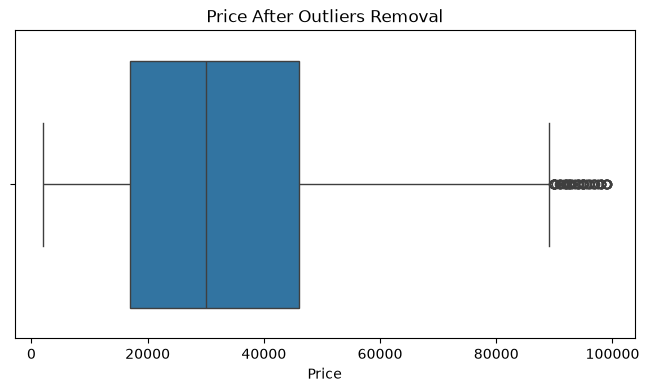

,Milage,Price
count,3700.000000,3700.000000
mean,65046.686757,33919.197027
std,46920.070373,21317.191155
min,100.000000,2000.000000
25%,26097.000000,16999.750000
50%,55950.000000,29995.000000
75%,94739.750000,45998.250000
max,202055.000000,99000.000000


In [50]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Price'], vert=False)

plt.title('Price After Outliers Removal')
plt.xlabel("Price")
plt.show()

df[["Milage","Price"]].describe()

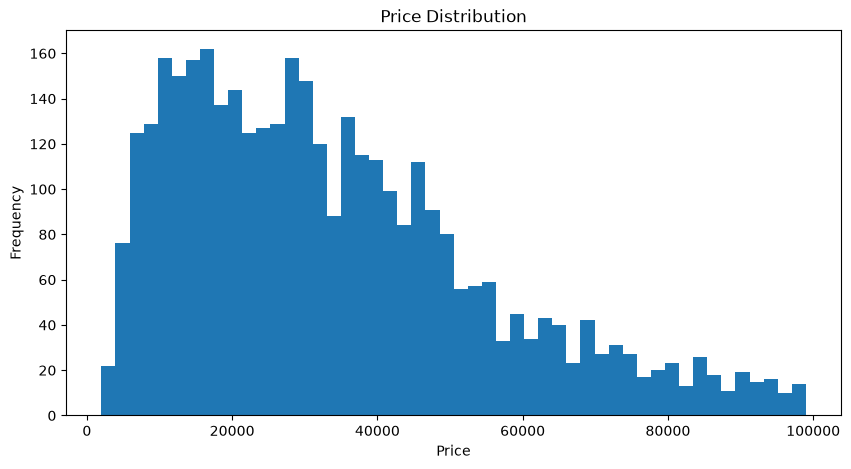

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(df['Price'], bins=50)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

In [52]:
numeric_cols= df.select_dtypes(include=['int64','float64']).columns
print("Numerical columns:")
print(numeric_cols)

Numerical columns:
Index(['Model_Year', 'Milage', 'Price'], dtype='str')


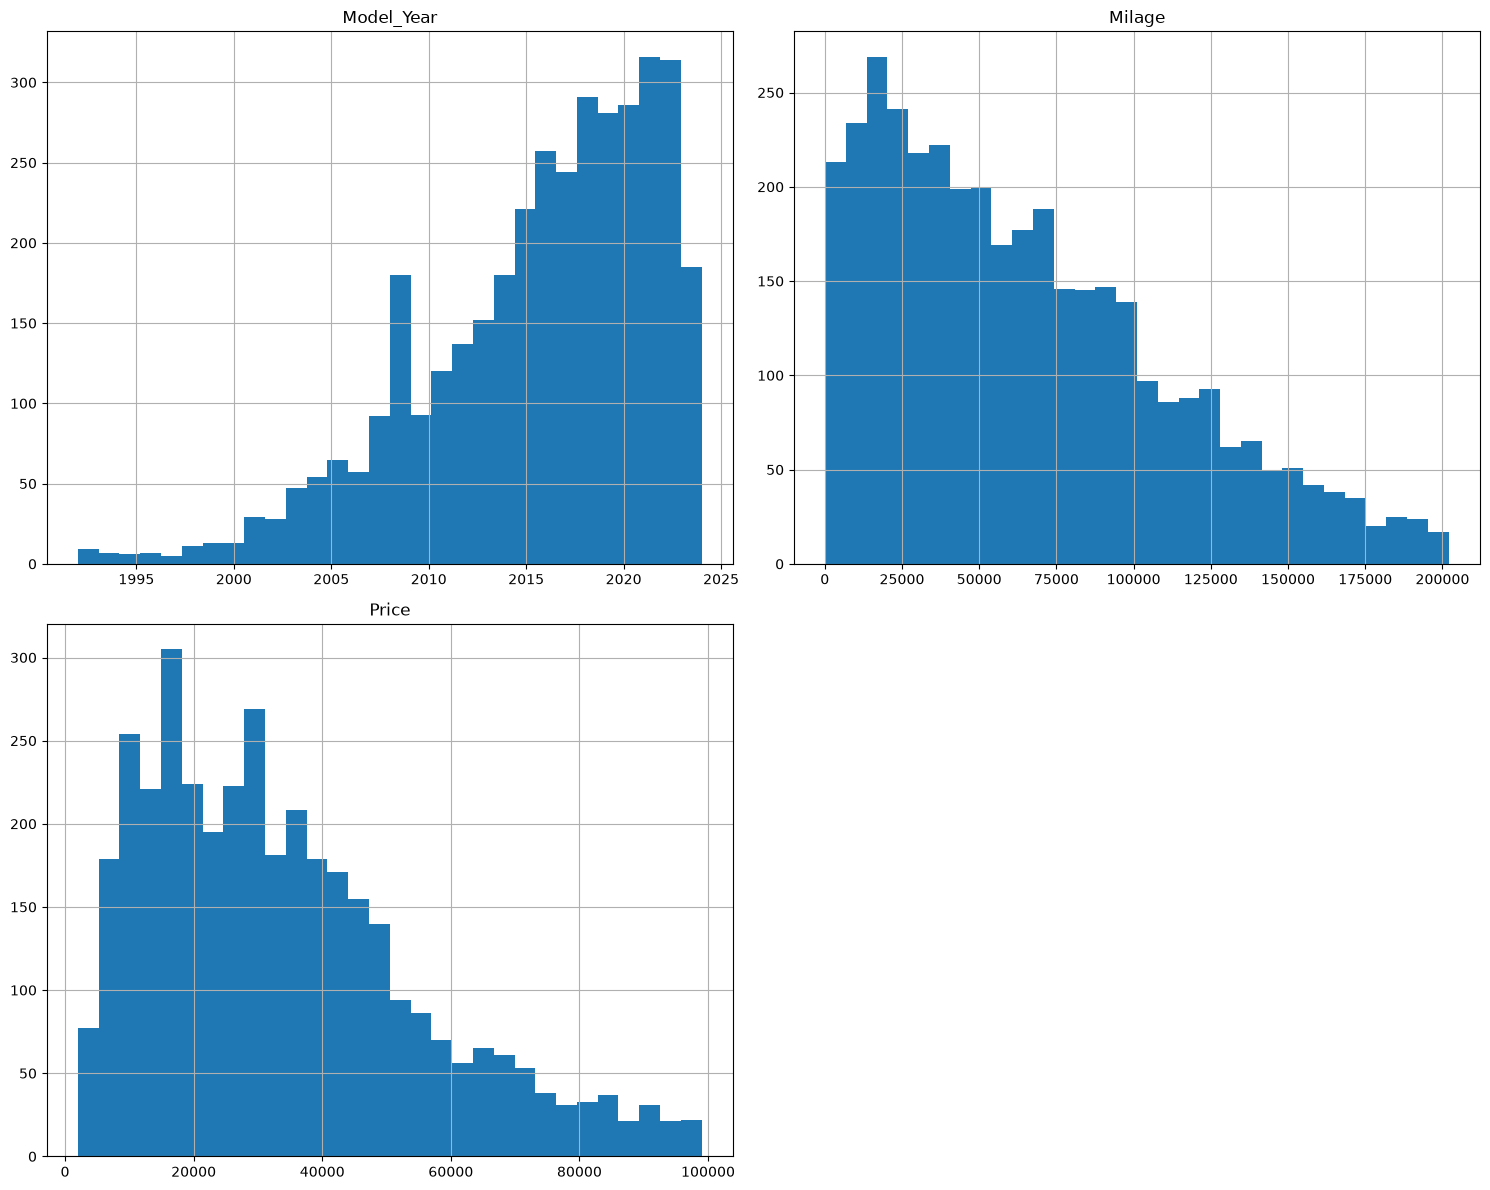

In [53]:
df[numeric_cols].hist(figsize=(15, 12),bins=30)
plt.tight_layout()
plt.show()

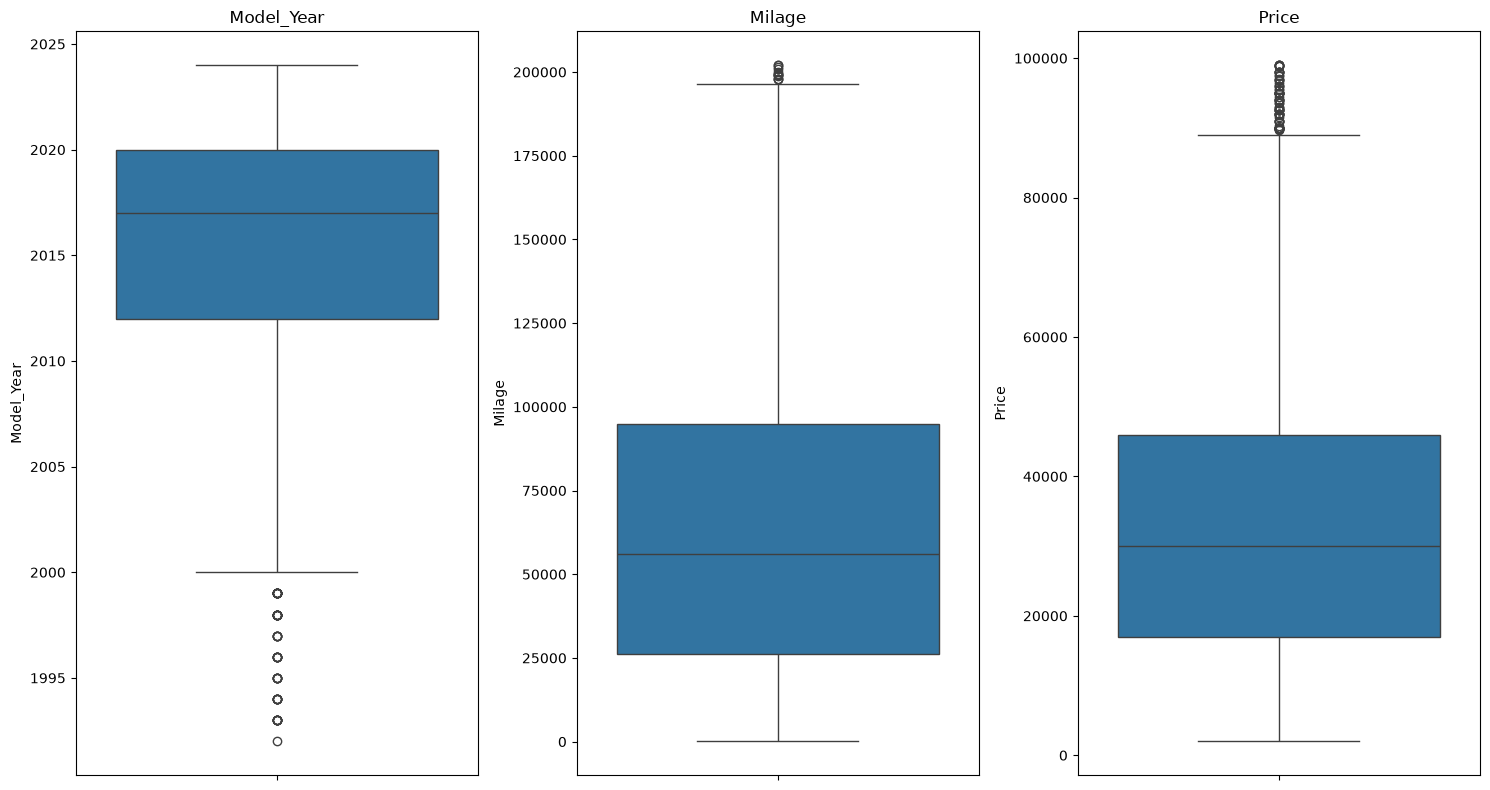

In [54]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols) + 2) // 3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [55]:
correlation = df[numeric_cols].corr()['Price'].sort_values(ascending=False)
print(correlation)

Price         1.000000
Model_Year    0.584310
Milage       -0.651379
Name: Price, dtype: float64


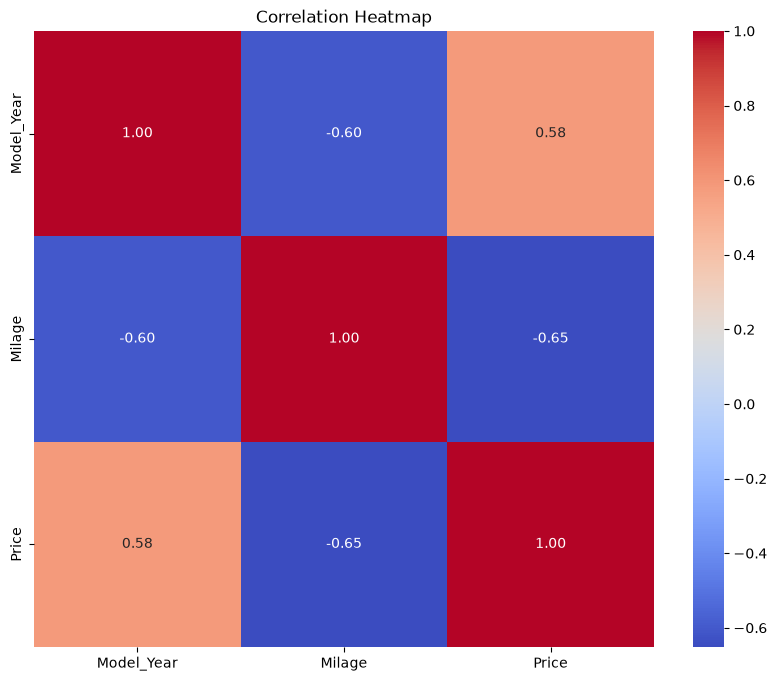

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

In [57]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(cat_cols)

Categorical columns:
Index(['Brand', 'Model', 'Fuel_Type', 'Engine_Type', 'Transmission',
       'Exterior_Color', 'Interior_Color', 'Accident_History', 'Clean_Title'],
      dtype='str')


In [58]:
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(15))


Brand
Unique values: 53
Brand
Ford             370
BMW              359
Chevrolet        280
Mercedes-Benz    277
Audi             188
Toyota           185
Lexus            154
Porsche          147
Jeep             142
Land             113
Nissan           110
Cadillac          99
RAM               91
GMC               87
Tesla             87
Name: count, dtype: int64

Model
Unique values: 1760
Model
M3 Base                 29
F-150 XLT               23
Corvette Base           22
1500 Laramie            18
Camaro 2SS              17
Model Y Long Range      17
Wrangler Sport          17
Mustang GT Premium      16
M4 Base                 15
Explorer XLT            14
F-250 Lariat            14
E-Class E 350           13
E-Class E 350 4MATIC    13
F-150 Lariat            13
ES 350 Base             12
Name: count, dtype: int64

Fuel_Type
Unique values: 7
Fuel_Type
Gasoline          3045
Hybrid             177
Unknown            165
E85 Flex Fuel      135
Diesel             103
–          

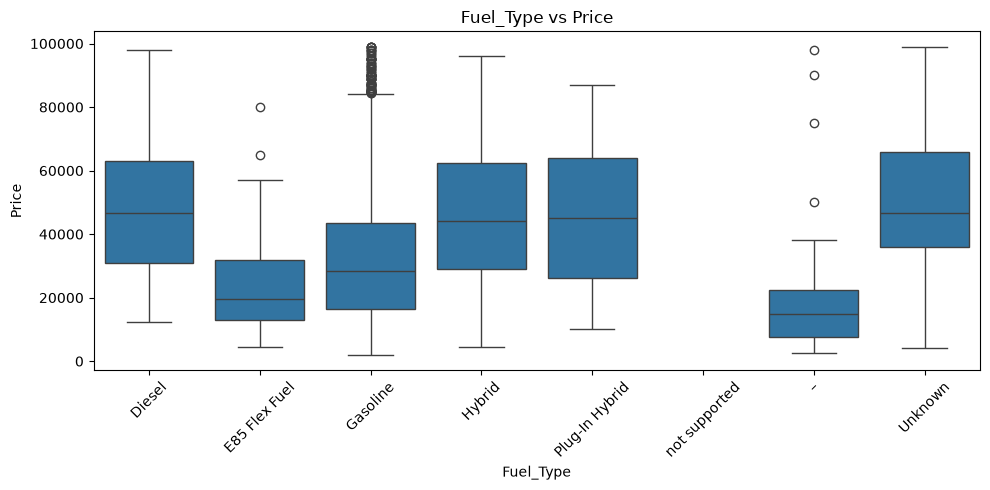

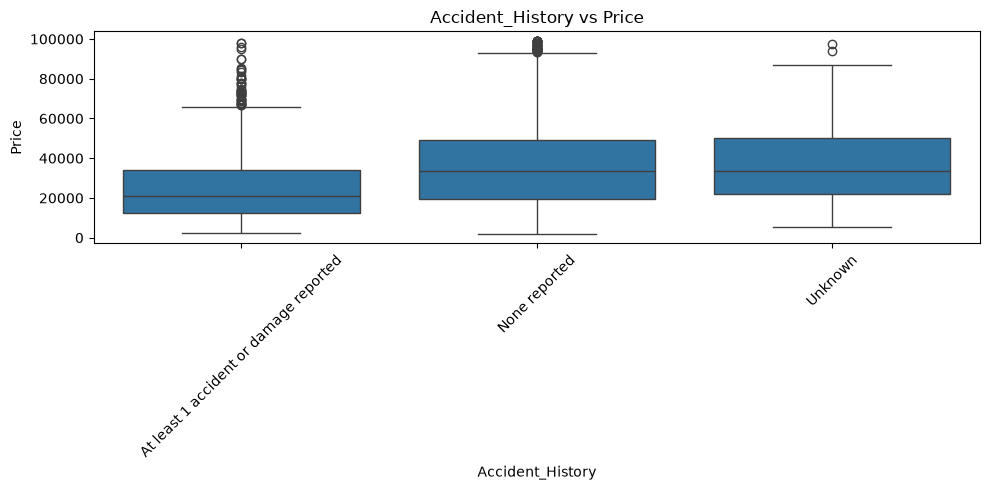

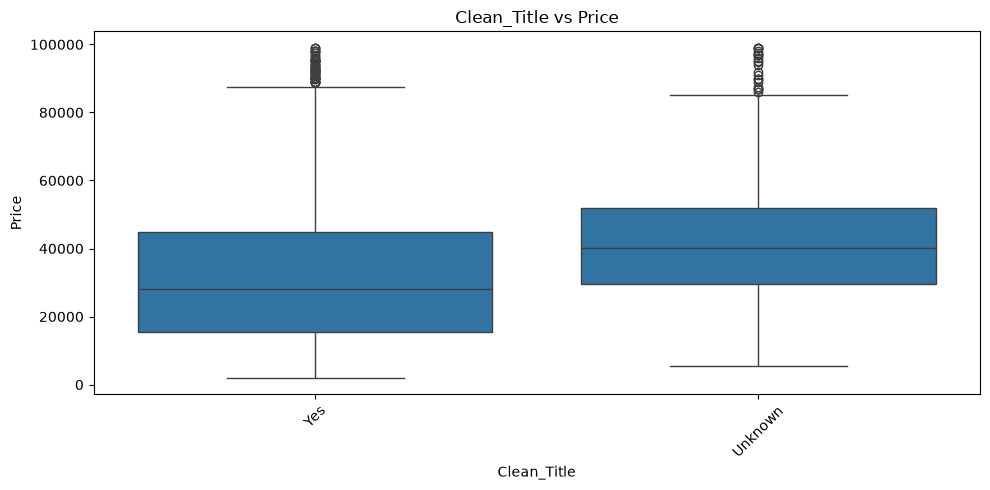

In [59]:
for col in cat_cols:
    if df[col].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x=col, y='Price')
        plt.xticks(rotation=45)
        plt.title(f'{col} vs Price')
        plt.tight_layout()
        plt.show()

In [60]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [61]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col != 'Price':
        df[col] = df[col].fillna(df[col].median())

In [62]:
df = df.dropna(subset=['Price'])

In [63]:
# unnecessary spaces
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [64]:
# Categorical features
print(df.columns)

Index(['Brand', 'Model', 'Model_Year', 'Milage', 'Fuel_Type', 'Engine_Type',
       'Transmission', 'Exterior_Color', 'Interior_Color', 'Accident_History',
       'Clean_Title', 'Price'],
      dtype='str')


In [65]:
df_copy = df.copy()

In [66]:
df.head()

,Brand,Model,Model_Year,Milage,Fuel_Type,Engine_Type,Transmission,Exterior_Color,Interior_Color,Accident_History,Clean_Title,Price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0


In [67]:
# OHE
print([col for col in df.columns.to_list() if df[col].dtype=='category'])

[]


In [68]:
cols = ['Brand', 'Model', 'Fuel_Type', 'Engine_Type', 'Transmission', 'Exterior_Color', 'Interior_Color', 'Accident_History', 'Clean_Title']

df_ohe = pd.get_dummies(df, columns=cols, dtype='int', drop_first=True)

df_ohe.head()

,Model_Year,Milage,Price,Brand_Alfa,Brand_Aston,Brand_Audi,Brand_BMW,Brand_Bentley,Brand_Buick,Brand_Cadillac,...,Interior_Color_WHITE,Interior_Color_Walnut,Interior_Color_Whisper Beige,Interior_Color_White,Interior_Color_White / Brown,Interior_Color_Yellow,Interior_Color_–,Accident_History_None reported,Accident_History_Unknown,Clean_Title_Yes
0,2013,51000,10300.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2021,34742,38005.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2022,22372,54598.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2015,88900,15500.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
4,2021,9835,34999.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [69]:
df_ohe.info()

<class 'pandas.DataFrame'>
Index: 3700 entries, 0 to 4008
Columns: 3319 entries, Model_Year to Clean_Title_Yes
dtypes: float64(1), int64(3318)
memory usage: 93.7 MB


In [70]:
print(df_ohe.shape)

(3700, 3319)


In [71]:
print(df_ohe.dtypes.value_counts())

int64      3318
float64       1
Name: count, dtype: int64


In [72]:
# SPLIT DATA
X = df_ohe.drop(columns=['Price'])
Y = df_ohe['Price']

In [73]:
X

,Model_Year,Milage,Brand_Alfa,Brand_Aston,Brand_Audi,Brand_BMW,Brand_Bentley,Brand_Buick,Brand_Cadillac,Brand_Chevrolet,...,Interior_Color_WHITE,Interior_Color_Walnut,Interior_Color_Whisper Beige,Interior_Color_White,Interior_Color_White / Brown,Interior_Color_Yellow,Interior_Color_–,Accident_History_None reported,Accident_History_Unknown,Clean_Title_Yes
0,2013,51000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2021,34742,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2022,22372,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2015,88900,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
4,2021,9835,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,2018,53705,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4005,2022,10900,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
4006,2022,2116,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4007,2020,33000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [74]:
Y

0       10300.0
1       38005.0
2       54598.0
3       15500.0
4       34999.0
         ...   
4003    25900.0
4005    53900.0
4006    90998.0
4007    62999.0
4008    40000.0
Name: Price, Length: 3700, dtype: float64

In [75]:
print(X.shape)
print(Y.shape)

(3700, 3318)
(3700,)


In [76]:
df_ohe.min(), df_ohe.max()

(Model_Year                        1992.0
 Milage                             100.0
 Price                             2000.0
 Brand_Alfa                           0.0
 Brand_Aston                          0.0
                                    ...  
 Interior_Color_Yellow                0.0
 Interior_Color_–                     0.0
 Accident_History_None reported       0.0
 Accident_History_Unknown             0.0
 Clean_Title_Yes                      0.0
 Length: 3319, dtype: float64,
 Model_Year                          2024.0
 Milage                            202055.0
 Price                              99000.0
 Brand_Alfa                             1.0
 Brand_Aston                            1.0
                                     ...   
 Interior_Color_Yellow                  1.0
 Interior_Color_–                       1.0
 Accident_History_None reported         1.0
 Accident_History_Unknown               1.0
 Clean_Title_Yes                        1.0
 Length: 3319, dtype: f

In [77]:
# Train-Test split
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

print("Training_data:", X_train.shape)
print("Testing_data:", X_test.shape)

Training_data: (2960, 3318)
Testing_data: (740, 3318)


In [79]:
# Model Building
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [80]:
model.fit(X_train, Y_train)
print("Model training completed")

Model training completed


In [81]:
model.intercept_

np.float64(-2247596.6958579947)

In [82]:
model.coef_

array([ 1.14368208e+03, -1.69301584e-01, -4.61609160e+03, ...,
        1.51662796e+03,  5.66649544e+02, -9.71291765e+02], shape=(3318,))

In [83]:
len(model.coef_)

3318

In [84]:
# MAKE PREDICTIONS
y_pred = model.predict(X_test)
y_pred

array([ 2.23090280e+04,  5.06000876e+04,  2.76305090e+04,  2.38346712e+04,
        2.42772534e+04,  6.87208889e+04,  4.78056449e+04,  5.16676338e+04,
        7.73207904e+04,  2.25659132e+04,  3.16344486e+04,  2.01690377e+04,
        2.56565558e+04,  4.68660346e+04,  6.65821649e+04,  3.45756577e+04,
        2.43862864e+04,  8.82762566e+03,  3.26560268e+04,  3.81409368e+04,
        3.35880391e+04,  9.39418663e+03,  2.01344819e+04,  6.08195504e+04,
        6.16174955e+04,  3.62341584e+04,  4.24525488e+04,  4.02849501e+04,
        2.29573587e+04,  4.24717808e+04,  8.48690328e+03,  2.48329267e+04,
        3.33683359e+04,  2.70806840e+04,  6.40516181e+04,  4.34488428e+04,
        4.02622065e+04,  1.49678250e+04,  4.13889927e+04,  2.02286586e+04,
        2.91615654e+04,  1.91837015e+04,  2.76942979e+04,  1.59210082e+04,
        1.36084593e+04,  2.56869797e+04,  2.27286618e+04,  1.52840558e+04,
        2.47665127e+04,  2.76188679e+04,  3.79094421e+04,  4.48999281e+04,
        3.94217702e+03,  

In [85]:
# Model Performence
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 8049.782267052283
MSE  : 120928761.4852097
RMSE : 10996.76140894262
R²   : 0.7371735533873598


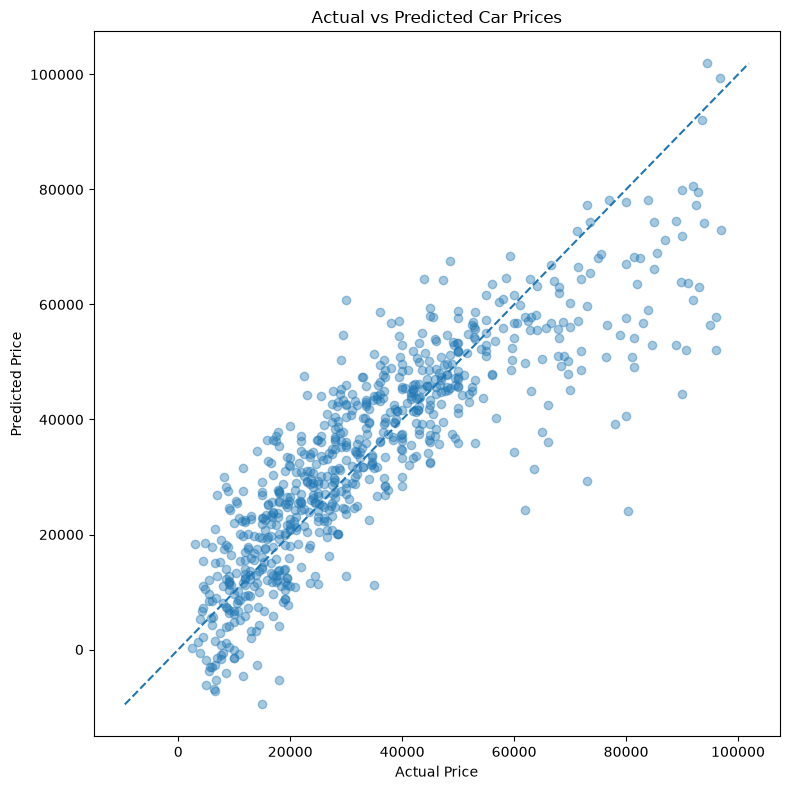

In [86]:
# ACTUAL VS PREDICTED PRICES
plt.figure(figsize=(8, 8))
plt.scatter(Y_test, y_pred, alpha=0.4)

min_value = min(Y_test.min(), y_pred.min())
max_value = max(Y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.tight_layout()
plt.show()

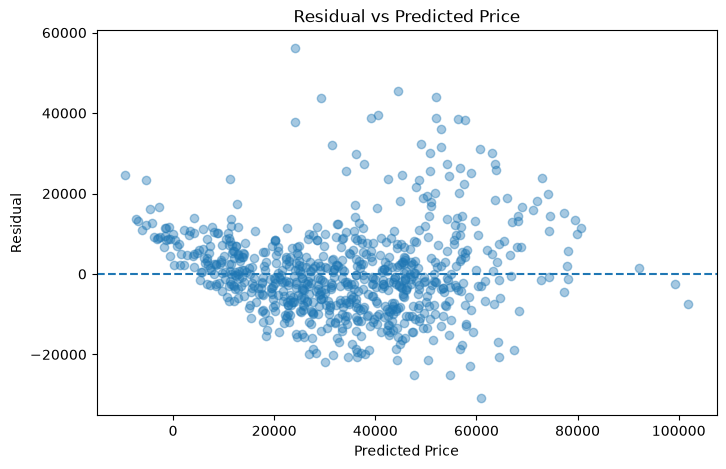

In [87]:
# RESIDUAL ANALYSIS
residuals = Y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual vs Predicted Price")

plt.show()